---
title: TRABAJO PRÁCTICO N° 4
subtitle: Clasificando pobres con la EPH, Metodos de Regularización y CART
author: Ricardo Javier Gutiérrez Vistín - Martín Gabriel Cargnel
date-format: "MMM, YYYY"
lang: es
execute:
  echo: true
  include: false
  fig-align: center
format:
  pdf:
    documentclass: scrartcl
    toc-depth: 2
    number-sections: true
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, recall_score, roc_curve, roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

Link al repositorio: https://github.com/mcargnel/Big-Data-UBA-Grupo-09/tree/main/TP4

{{< pagebreak >}}

In [3]:
respondieron = pd.read_parquet('/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/TP4/data/respondieron.parquet')
norespondieron = pd.read_parquet('/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/TP4/data/norespondieron.parquet')

In [4]:
respondieron_2025 = respondieron[respondieron['ano4'] == 2025].copy()
respondieron_2025 = respondieron_2025.reset_index(drop=True).drop(columns=['ano4'])
respondieron_2005 = respondieron[respondieron['ano4'] == 2005].copy()
respondieron_2005 = respondieron_2005.reset_index(drop=True).drop(columns=['ano4'])


norespondieron_2005 = norespondieron[norespondieron['ano4'] == 2005].copy()
norespondieron_2005 = norespondieron_2005.reset_index(drop=True).drop(columns=['ano4'])
norespondieron_2025 = norespondieron[norespondieron['ano4'] == 2025].copy()
norespondieron_2025 = norespondieron_2025.reset_index(drop=True).drop(columns=['ano4'])

In [5]:
X = respondieron_2025.drop(columns=['pobre'])
y = respondieron_2025['pobre']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 444)

# Modelo de Regresión Logística con Regularización: Ridge y LASSO

## Visualización

In [ ]:
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)

In [ ]:
C_grid = np.logspace(-4, 4, 100)

coefs_lasso = []
coefs_ridge = []

for C in C_grid:

    log_reg_ridge = LogisticRegression(C=C, penalty='l2', solver='saga', max_iter=5000, random_state=42)
    log_reg_ridge.fit(X_train_scaled, y_train)
    coefs_ridge.append(log_reg_ridge.coef_.ravel())
    
    
    log_reg_lasso = LogisticRegression(C=C, penalty='l1', solver='saga', max_iter=5000, random_state=42)
    log_reg_lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(log_reg_lasso.coef_.ravel())

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

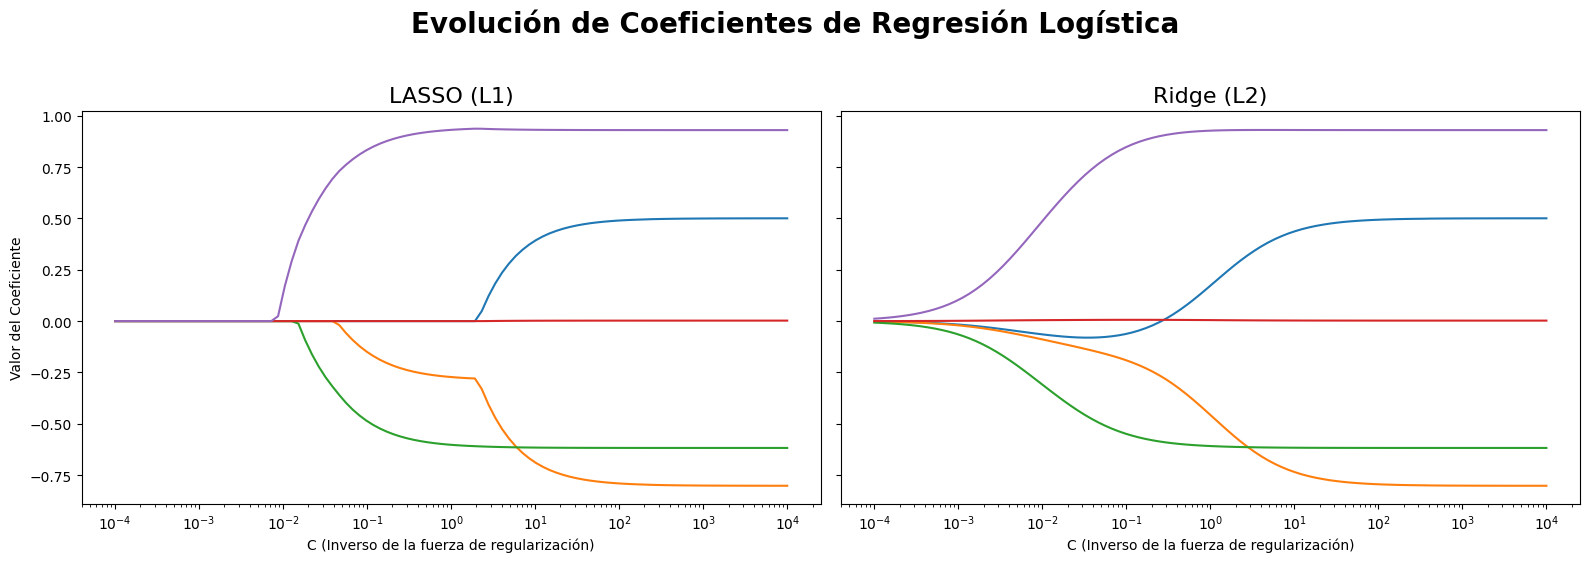

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ax[0].plot(C_grid, coefs_lasso)
ax[0].set_xscale('log')
ax[0].set_title('LASSO (L1)', fontsize=16)
ax[0].set_xlabel('C (Inverso de la fuerza de regularización)')
ax[0].set_ylabel('Valor del Coeficiente')

ax[1].plot(C_grid, coefs_ridge)
ax[1].set_xscale('log')
ax[1].set_title('Ridge (L2)', fontsize=16)
ax[1].set_xlabel('C (Inverso de la fuerza de regularización)')

fig.suptitle('Evolución de Coeficientes de Regresión Logística', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## Penalidad óptima por Cross-validation y visualización

In [88]:
reg_log_ridge_cv = LogisticRegressionCV(Cs = C_grid,penalty='l2',solver='saga', cv=5, random_state=444, max_iter=1000)
reg_log_ridge_cv.fit(X_train_scaled, y_train)

reg_log_lasso_cv = LogisticRegressionCV(Cs = C_grid,penalty='l1',solver='saga', cv=5, random_state=444, max_iter=1000)
reg_log_lasso_cv.fit(X_train_scaled, y_train)

,Cs,array([ 0....000. ])
,fit_intercept,True
,cv,5
,dual,False
,penalty,'l1'
,scoring,None
,solver,'saga'
,tol,0.0001
,max_iter,1000
,class_weight,None
,n_jobs,None


In [ ]:
# This is the optimal C value
optimal_c_ridge = reg_log_ridge_cv.C_[0] 
optimal_c_lasso = reg_log_lasso_cv.C_[0] 

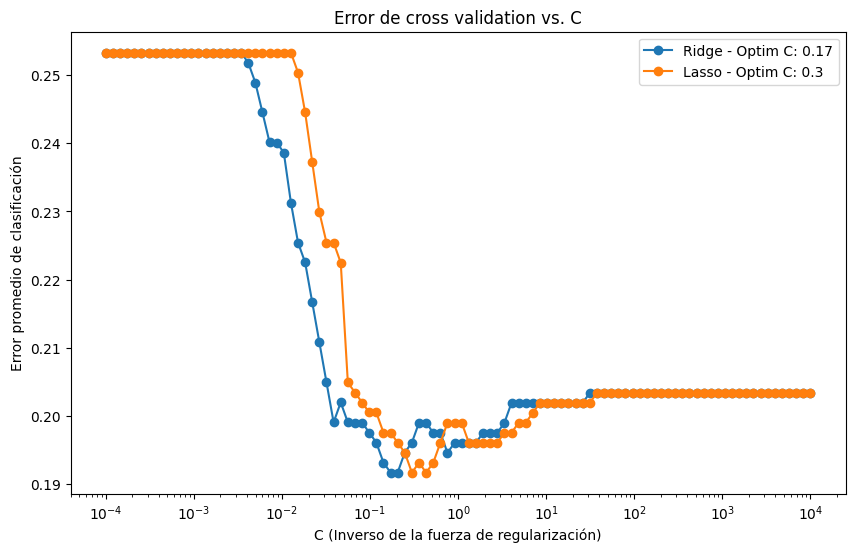

In [95]:
c_values = reg_log_ridge_cv.Cs_

mean_accuracy_ridge = np.mean(reg_log_ridge_cv.scores_[1], axis=0)
mean_accuracy_lasso = np.mean(reg_log_lasso_cv.scores_[1], axis=0)

mean_classification_error_ridge = 1 - mean_accuracy_ridge
mean_classification_error_lasso = 1 - mean_accuracy_lasso

plt.figure(figsize=(10, 6))
plt.plot(c_values, mean_classification_error_ridge, marker='o', label=f'Ridge - Optim C: {optimal_c_ridge.round(2)}')
plt.plot(c_values, mean_classification_error_lasso, marker='o', label=f'Lasso - Optim C: {optimal_c_lasso.round(2)}')
plt.xlabel('C (Inverso de la fuerza de regularización)')
plt.ylabel('Error promedio de clasificación')
plt.title('Error de cross validation vs. C')
plt.xscale('log')
plt.legend()
plt.show()

## Estimacion con $\lambda^{cv}$ y comparacion de coeficientes

In [145]:
reg_log = LogisticRegression(penalty=None, random_state=42, max_iter=1000)
reg_log.fit(X_train, y_train)
reg_log_ridge = LogisticRegression(C = optimal_c_ridge,penalty='l2', random_state=42, solver='saga', max_iter=1000)
reg_log_ridge.fit(X_train_scaled, y_train)
reg_log_lasso = LogisticRegression(C = optimal_c_ridge, penalty='l1', random_state=42, solver='saga', max_iter=1000)
reg_log_lasso.fit(X_train_scaled, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,np.float64(0.1707352647470692)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [146]:
df_coeffs = pd.DataFrame({
    'Vars': X_train.columns,
    'Sin Penalidad': reg_log.coef_.ravel(),
    'Ridge': reg_log_ridge.coef_.ravel(),
    'Lasso': reg_log_lasso.coef_.ravel() 
}).round(2)

df_coeffs

,Vars,Sin Penalidad,Ridge,Lasso
0,ch06,0.04,-0.03,0.00
1,edad2,-0.00,-0.23,-0.20
2,educ,-0.16,-0.57,-0.54
3,horastrab,0.00,0.01,0.00
4,ix_tot,0.65,0.88,0.88


# Árboles de Decisión

## Estimación

In [147]:
clf_base = DecisionTreeClassifier(random_state=444)

path = clf_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [148]:
param_grid = {
    'ccp_alpha': ccp_alphas
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=444),
    param_grid=param_grid,
    cv=10,
    scoring='accuracy'
)

grid_search.fit(X_train_scaled, y_train)

,estimator,DecisionTreeC...dom_state=444)
,param_grid,{'ccp_alpha': array([0. ... 0.03996688])}
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


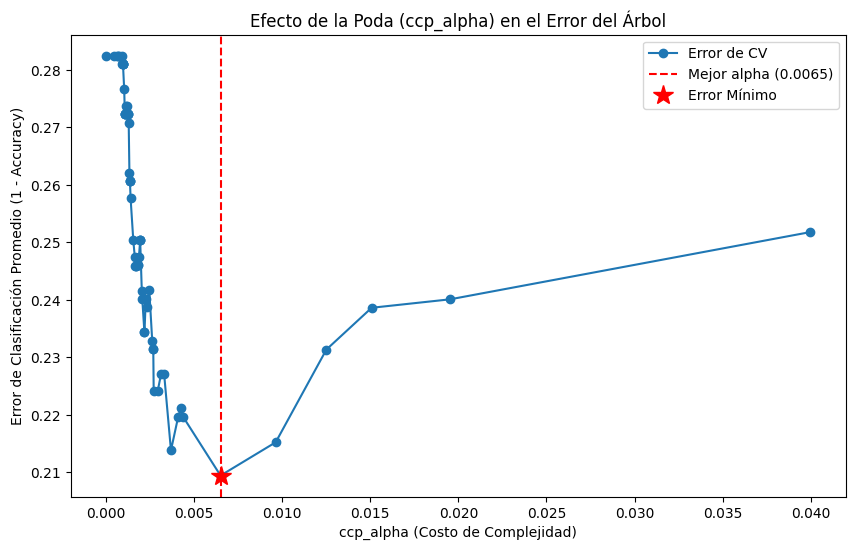

In [149]:
results = grid_search.cv_results_
mean_accuracy_scores = results['mean_test_score']

mean_classification_error = 1 - mean_accuracy_scores

alphas = results['param_ccp_alpha'].data

plt.figure(figsize=(10, 6))
plt.plot(alphas, mean_classification_error, marker='o', label='Error de CV')

best_alpha = grid_search.best_params_['ccp_alpha']
best_error = 1 - grid_search.best_score_
plt.axvline(x=best_alpha, linestyle='--', color='r', label=f'Mejor alpha ({best_alpha:.4f})')
plt.plot(best_alpha, best_error, 'r*', markersize=15, label='Error Mínimo')

plt.xlabel('ccp_alpha (Costo de Complejidad)')
plt.ylabel('Error de Clasificación Promedio (1 - Accuracy)')
plt.title('Efecto de la Poda (ccp_alpha) en el Error del Árbol')
plt.legend()
plt.show()

## Visualización del árbol podado por cross-validation

In [150]:
feature_names = X_train.columns.tolist() 

class_names = [str(c) for c in sorted(y_train.unique())]

best_pruned_tree = grid_search.best_estimator_

# 1. Obtener las importancias del mejor árbol
importances = best_pruned_tree.feature_importances_

# 2. Crear un DataFrame para facilitar la visualización
feature_importance_df = pd.DataFrame(
    {'feature': feature_names, 'importance': importances}
).sort_values(by='importance', ascending=True) # Ordenar de menor a mayor


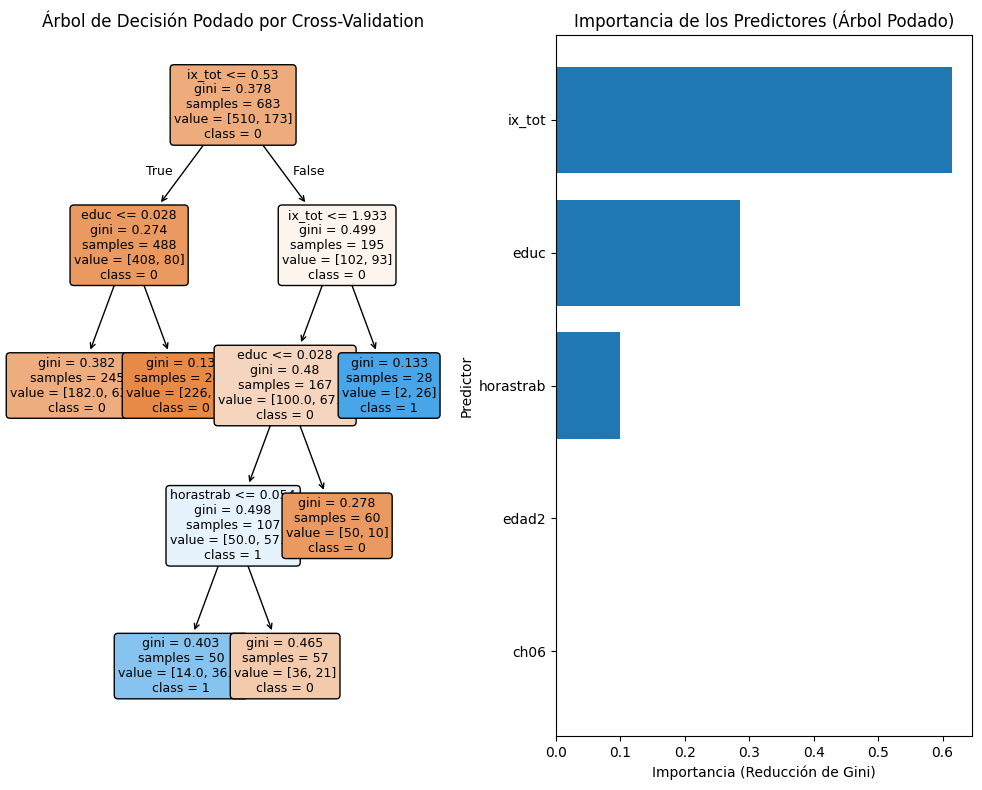

In [151]:
fig, ax = plt.subplots(1, 2, figsize=(10, 8)) # Ajusta el tamaño de la figura completa

plot_tree(
    best_pruned_tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    precision=3,
    fontsize=9,
    ax=ax[0]   
)
ax[0].set_title("Árbol de Decisión Podado por Cross-Validation")

ax[1].barh(
    feature_importance_df['feature'],
    feature_importance_df['importance']
)
ax[1].set_xlabel("Importancia (Reducción de Gini)")
ax[1].set_ylabel("Predictor")
ax[1].set_title("Importancia de los Predictores (Árbol Podado)")

plt.tight_layout()
plt.show()

# Comparación de métodos

In [153]:
from sklearn.neighbors import KNeighborsClassifier

In [154]:
reg_log_pred = reg_log.predict(X_test)
reg_log_pred_proba = reg_log.predict_proba(X_test)[:, 1]

knn_final = KNeighborsClassifier(n_neighbors=4)
knn_final.fit(X_train, y_train)

knn_pred = knn_final.predict(X_test)
knn_pred_proba = knn_final.predict_proba(X_test)[:, 1] 

X_test_scaled = sc.fit_transform(X_test)

reg_log_ridge_pred = reg_log_ridge.predict(X_test_scaled)
reg_log_ridge_pred_proba = reg_log_ridge.predict_proba(X_test_scaled)[:, 1]

reg_log_lasso_pred = reg_log_lasso.predict(X_test_scaled)
reg_log_lasso_pred_proba = reg_log_lasso.predict_proba(X_test_scaled)[:, 1]

tree_pred = best_pruned_tree.predict(X_test)
tree_pred_proba = best_pruned_tree.predict_proba(X_test)[:, 1]

/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [156]:
print(pd.crosstab(index=y_test, columns=reg_log_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))
print(pd.crosstab(index=y_test, columns=knn_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))
print(pd.crosstab(index=y_test, columns=reg_log_ridge_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))
print(pd.crosstab(index=y_test, columns=reg_log_lasso_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))
print(pd.crosstab(index=y_test, columns=tree_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))

col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                 215           15
1                  39           25
col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                 223            7
1                  60            4
col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                 218           12
1                  43           21
col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                 217           13
1                  43           21
col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                  79          151
1                   3           61


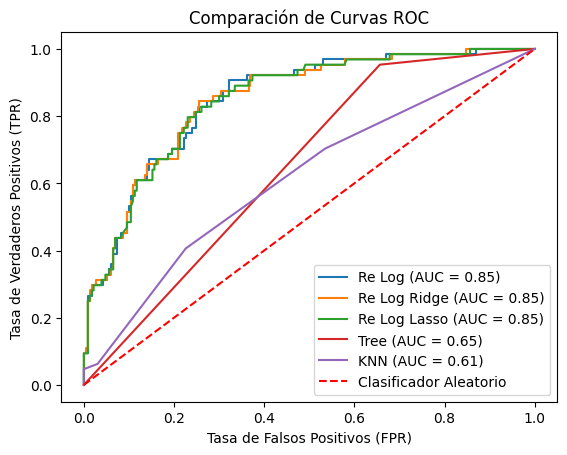

In [ ]:
#| label: fig-roc-curve
#| fig-cap: Gráfico con curvas ROC para regresión logística, Reg Log Ridge, Reg Log Lasso, Tree y KNN.
#| echo: false
#| include: true

fpr_log, tpr_log, _ = roc_curve(y_test, reg_log_pred_proba)
auc_log = roc_auc_score(y_test, reg_log_pred_proba)

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_pred_proba)
auc_knn = roc_auc_score(y_test, knn_pred_proba)

fpr_log_ridge, tpr_log_ridge, _ = roc_curve(y_test, reg_log_ridge_pred_proba)
auc_log_ridge = roc_auc_score(y_test, reg_log_ridge_pred_proba)

fpr_log_lasso, tpr_log_lasso, _ = roc_curve(y_test, reg_log_lasso_pred_proba)
auc_log_lasso = roc_auc_score(y_test, reg_log_lasso_pred_proba)

fpr_log_tree, tpr_log_tree, _ = roc_curve(y_test, tree_pred_proba)
auc_log_tree = roc_auc_score(y_test, tree_pred_proba)

plt.figure()

plt.plot(fpr_log, tpr_log, label=f'Re Log (AUC = {auc_log:.2f})')

plt.plot(fpr_log_ridge, tpr_log_ridge, label=f'Re Log Ridge (AUC = {auc_log_ridge:.2f})')

plt.plot(fpr_log_lasso, tpr_log_lasso, label=f'Re Log Lasso (AUC = {auc_log_lasso:.2f})')

plt.plot(fpr_log_tree, tpr_log_tree, label=f'Tree (AUC = {auc_log_tree:.2f})')

plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')

plt.title('Comparación de Curvas ROC')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend()

plt.show()

In [ ]:
#| label: tab-metrics
#| tab-cap: Tabla con accuracy y recall para en la muestra de testeo para la regresión logística, KNN, Reg Log Ridge, Reg Log Lasso y Tree.
#| echo: false
#| include: true

metricas = {
    'Reg Log': [
        accuracy_score(y_test, reg_log_pred),
        recall_score(y_test, reg_log_pred)
    ],
    'KNN': [
        accuracy_score(y_test, knn_pred),
        recall_score(y_test, knn_pred)
    ],
    'Reg Log Ridge': [
        accuracy_score(y_test, reg_log_ridge_pred),
        recall_score(y_test, reg_log_ridge_pred)
    ],
    'Reg Log Lasso': [
        accuracy_score(y_test, reg_log_lasso_pred),
        recall_score(y_test, reg_log_lasso_pred)
    ],
    'Tree': [
        accuracy_score(y_test, tree_pred),
        recall_score(y_test, tree_pred)
    ]
}

df_resultados = pd.DataFrame(metricas, index=['Accuracy', 'Recall'])
df_resultados

,Reg Log,KNN,Reg Log Ridge,Reg Log Lasso,Tree
Accuracy,0.816327,0.772109,0.812925,0.809524,0.476190
Recall,0.390625,0.062500,0.328125,0.328125,0.953125
